<h1 style="color: #0D47A1; font-weight: bold">
    Entrega TP3
</h1>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch import nn
from tqdm import tqdm

from copy import deepcopy

In [3]:
sys.path.append("..")

from src.utils.plotting import (plot_random_images, plot_training_history,
    evaluate_model, compare_models, plot_model_metric_comparison)
from src.utils.preprocessing import (data_split, scaler)
from src.evaluation.grid_search import random_grid_search_custom, random_grid_search_torch
from src.training.train import train_and_eval, train_loop
from src.utils.utils import get_best_config
from src.evaluation.predictions import get_predictions
from src.evaluation.noise_robustness import evaluate_noise_robustness

from src.models.custom.layers import DenseLayer
from src.models.custom.neural_network import SecuentialNeuralNetwork
from src.models.custom.activations import ReLU, SoftMax
from src.models.custom.optimizers import GradientDescent, ADAM
from src.models.custom.loss import CrossEntropy
from src.models.torch.mlp import MLP

<h2 style="color: #1976D2; font-weight: 500">
    1. Análisis exploratorio y preprocesamiento
</h2>

In [4]:
X_images = np.load("../data/X_images.npy")
y_images = np.load("../data/y_images.npy")

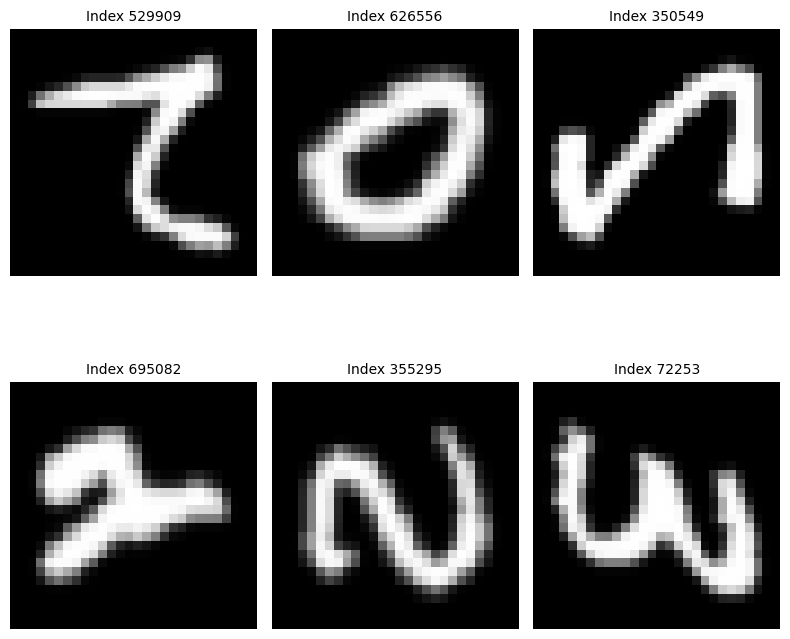

In [5]:
plot_random_images(X_images, image_shape=(28, 28), n=6)

In [6]:
X_images = X_images.reshape(X_images.shape[0], -1)

In [7]:
output_dim = len(set(y_images.tolist()))
print("Cantidad de clases:", output_dim)

Cantidad de clases: 47


In [8]:
input_dim = X_images.shape[1]
print("Cantidad de features:", input_dim)

Cantidad de features: 784


In [9]:
rows = X_images.shape[0]
print("Cantidad de muestras:", rows)

Cantidad de muestras: 809555


# BORRAR

In [10]:
search_size = int(min(X_images.shape[0]*0.1, X_images.shape[0]))

search_idx = np.random.choice(X_images.shape[0], size=search_size, replace=False)

X_images = X_images[search_idx]
y_images = y_images[search_idx]

In [11]:
rows = X_images.shape[0]
print(rows)

80955


Normalizo el dataset dividiendo por 255 así el máximo es 1.

Luego:

Dividir en Train, Validation y Test
- Dev 0.9, Test 0.1
- Train 7/9 de Dev, Val 2/9 de Dev

Sobre el dataset total:
- Train 0.7, Val 0.2, Test 0.1

In [12]:
X_images = scaler(X_images)

# Shuffle and split
X_dev, y_dev, X_test, y_test = data_split(X_images, y_images, frac=0.8)
X_train, y_train, X_val, y_val = data_split(X_dev, y_dev, frac=7/9)

del X_images
del y_images

Total de épocas para los modelos a evaluar

In [13]:
total_epochs = 150

<h2 style="color: #1976D2; font-weight: 500">
    2. Implementación y Entrenamiento de una Red Neuronal Básica
</h2>

Incisos **a** y **b** en `src/models/`

<h3 style="color: #00B0FF; font-weight: 400">
    Modelo M0
</h3>

- 1ra capa oculta:
    - 128 nodos con activación ReLU
- 2da capa oculta:
    - 64 nodos con activación ReLU
- Capa de salida:
    - 47 nodos con activación SoftMax

In [14]:
layers_m0 = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m0 = SecuentialNeuralNetwork(
    layers_m0, 
    GradientDescent(learning_rate=0.05), 
    CrossEntropy()
)

m0_test = deepcopy(m0)

**Entrenamiento del modelo**

In [15]:
last_epoch_m0 = m0.fit(X=X_train, y=y_train, epochs=total_epochs, batch_size=None, X_val=X_val, y_val=y_val, early_stopping=None)

Training: 100%|██████████| 150/150 [00:21<00:00,  7.02ep/s]


**Evolución de la función de costo**

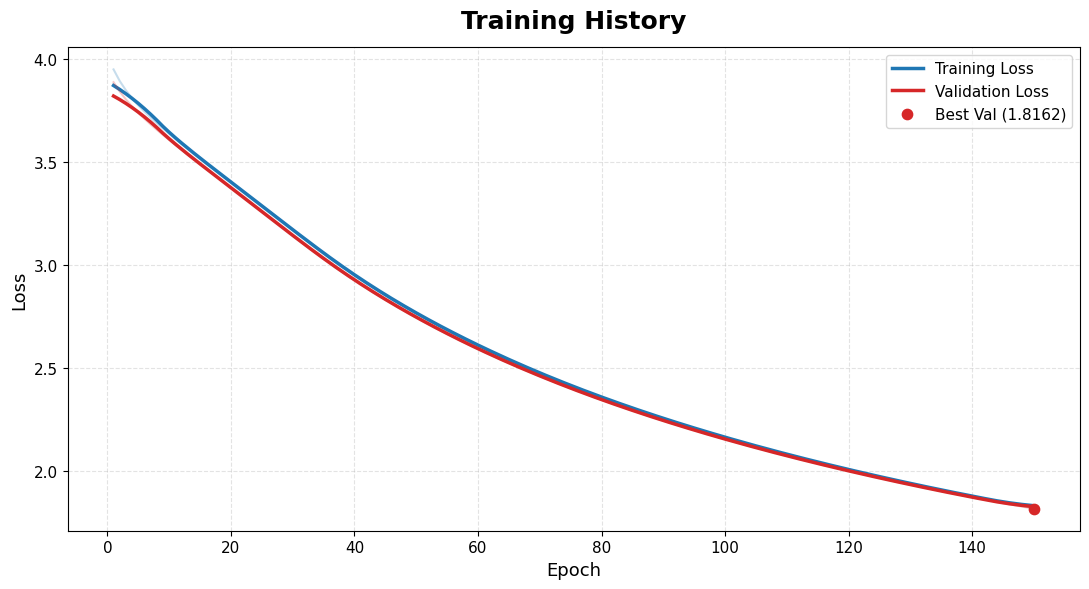

In [16]:
plot_training_history(m0.train_loss, m0.val_loss)

El modelo **M0** no llegó a su óptimo en 150 épocas, sin embargo, la limitación en el entrenamiento se debe a que cada actualización requiere procesar el conjunto completo de entrenamiento suponiendo un costo de entrenamiento significativamente mayor que el resto de modelos. Dado que el objetivo principal de este modelo es servir como baseline, esta decisión no compromete la comparación cualitativa con los modelos optimizados.

**Métricas de performance**

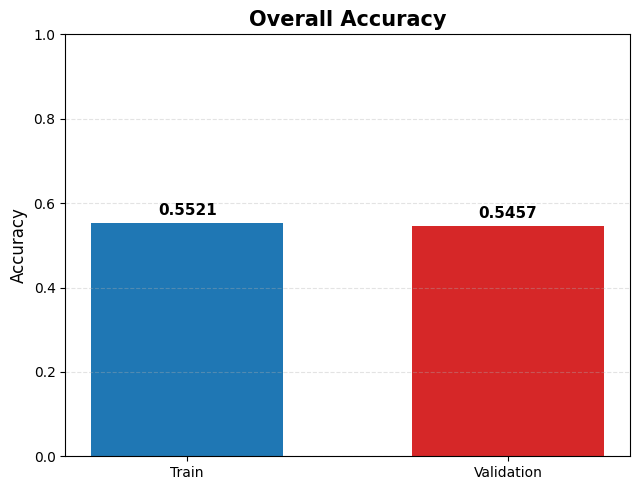

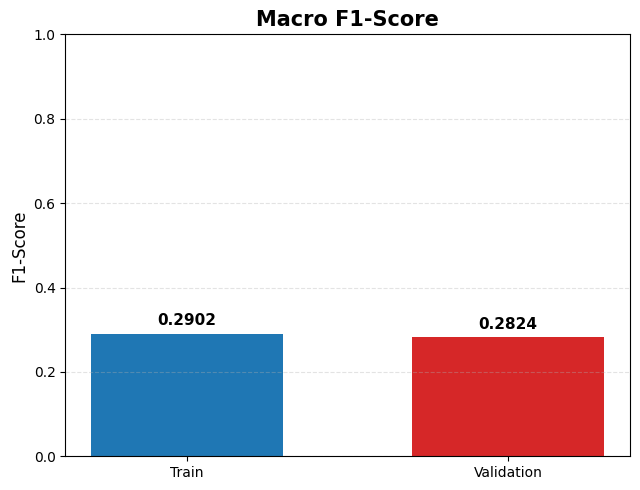

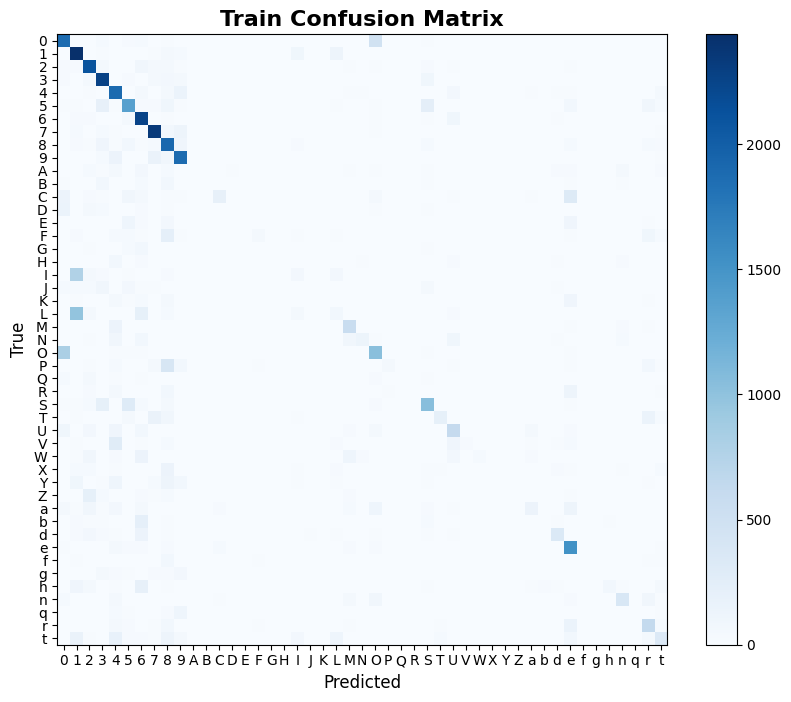

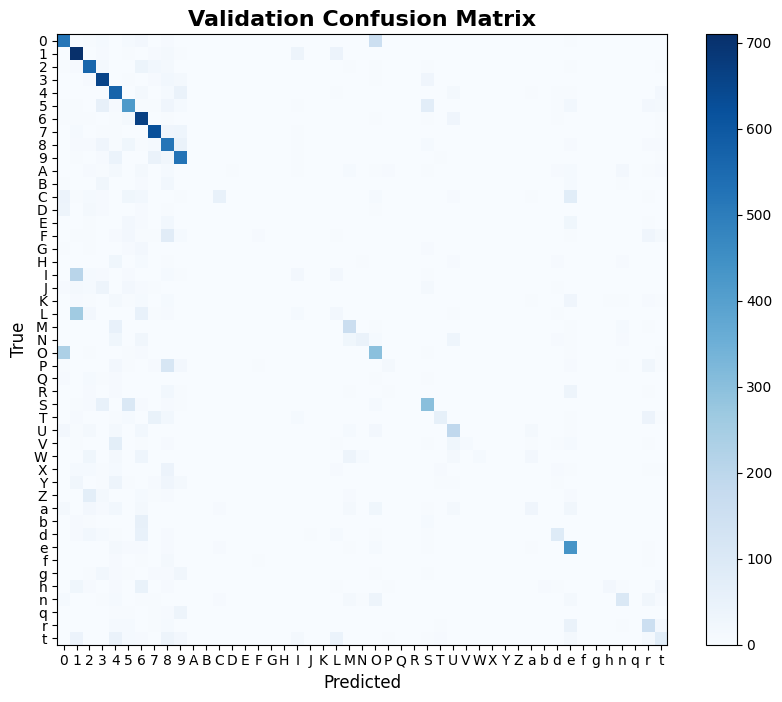

In [17]:
evaluate_model(m0, X_train, y_train, X_val, y_val)

<h2 style="color: #1976D2; font-weight: 500">
    3. Implementación y Entrenamiento de una Red Neuronal Avanzada
</h2>

**Mejoras al algoritmo de entrenamiento y reporte de los efectos observados sobre el tiempo de entrenamiento y la performance del modelo resultante**

**Implementaciones:**
- **Épocas a evaluar:** 50
- **Tamaño del dataset:** se utiliza el 20% del tamaño original de los conjuntos de train y validation, seleccionado aleatoriamente. Para EMNIST ByMerge, esto corresponde aproximadamente a 113k muestras de train y 32k de validation. Esta decisión se toma porque el objetivo no es alcanzar la máxima performance posible sobre el dataset completo, sino comparar la variación en tiempo de entrenamiento y desempeño al aplicar distintas mejoras de manera aislada.
- **Diseño a utilizar:**
    - 1ra capa oculta:
        - 128 nodos con activación ReLU
    - 2da capa oculta:
        - 64 nodos con activación ReLU
    - Capa de salida:
        - 47 nodos con activación SoftMax

In [18]:
epochs_test = 50

search_train_size = int(min(X_train.shape[0]*0.2, X_train.shape[0]))
search_val_size = int(min(X_val.shape[0]*0.2, X_val.shape[0]))

search_train_idx = np.random.choice(X_train.shape[0], size=search_train_size, replace=False)
search_val_idx = np.random.choice(X_val.shape[0], size=search_val_size, replace=False)

X_train_search = X_train[search_train_idx]
y_train_search = y_train[search_train_idx]
X_val_search = X_val[search_val_idx]
y_val_search = y_val[search_val_idx]

- **Rate scheduling lineal (con saturación)**

In [19]:
linear_scheduling = {"type": "linear", "lr_min": 0.001, "k": 0.01}

layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    GradientDescent(learning_rate=0.01, scheduling=linear_scheduling), 
    CrossEntropy()
)

In [20]:
_ = m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 50/50 [00:01<00:00, 35.46ep/s]


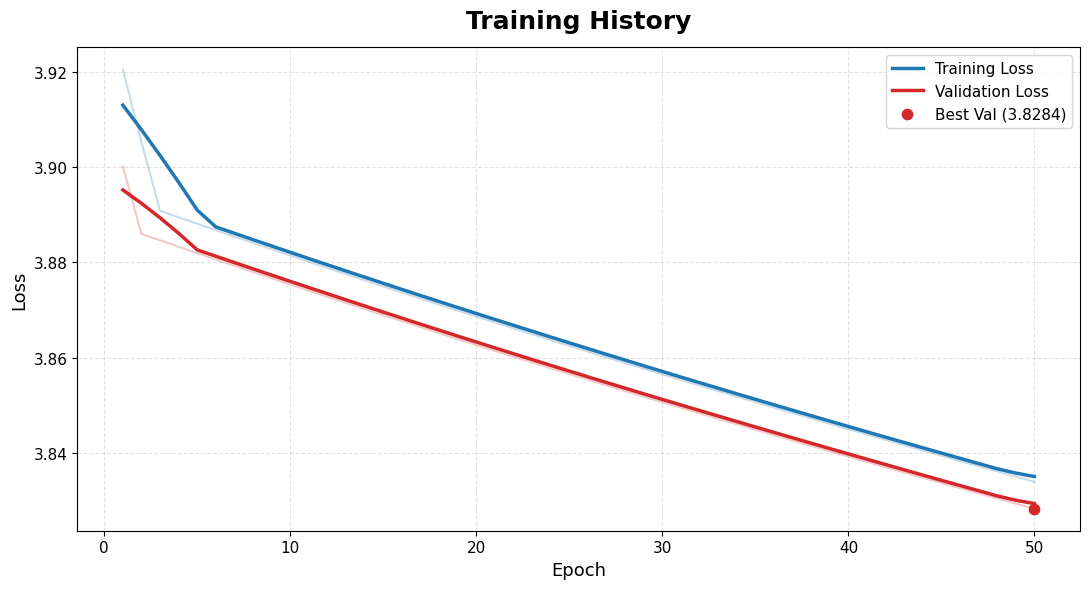

In [21]:
plot_training_history(m_test.train_loss, m_test.val_loss)

Se observa que incorporar linear scheduling sin otras mejoras empeora el entrenamiento del modelo en esta configuración. Una posible explicación es que la tasa de aprendizaje disminuye progresivamente, haciendo que las actualizaciones de los parámetros sean cada vez más pequeñas y pudiendo ralentizar la convergencia antes de alcanzar una buena solución.

- **Rate scheduling exponencial**

In [22]:
exponential_scheduling = {"type": "exponential", "gamma": 0.9}

layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    GradientDescent(learning_rate=0.01, scheduling=exponential_scheduling), 
    CrossEntropy()
)

In [23]:
_ = m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 50/50 [00:01<00:00, 37.48ep/s]


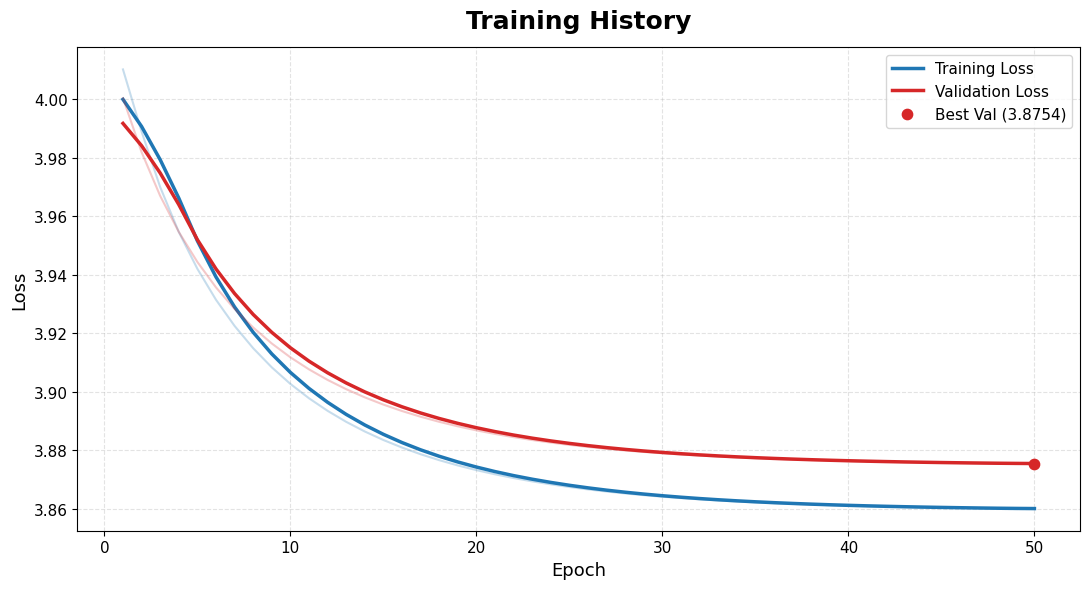

In [24]:
plot_training_history(m_test.train_loss, m_test.val_loss)

Al incorporar exponential scheduling, se observó una evolución más curva en el historial de entrenamiento, consistente con una disminución no lineal de la tasa de aprendizaje. Sin embargo, de forma aislada no representó una mejora significativa en el desempeño. Al igual que con linear scheduling, su aplicación sin combinarse con otras técnicas de optimización resultó poco efectiva e incluso potencialmente perjudicial en esta configuración experimental.

- **Mini-batch stochastic gradient descent**

In [25]:
layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    GradientDescent(learning_rate=0.01), 
    CrossEntropy()
)

In [26]:
_ = m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=128, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 50/50 [00:08<00:00,  5.81ep/s]


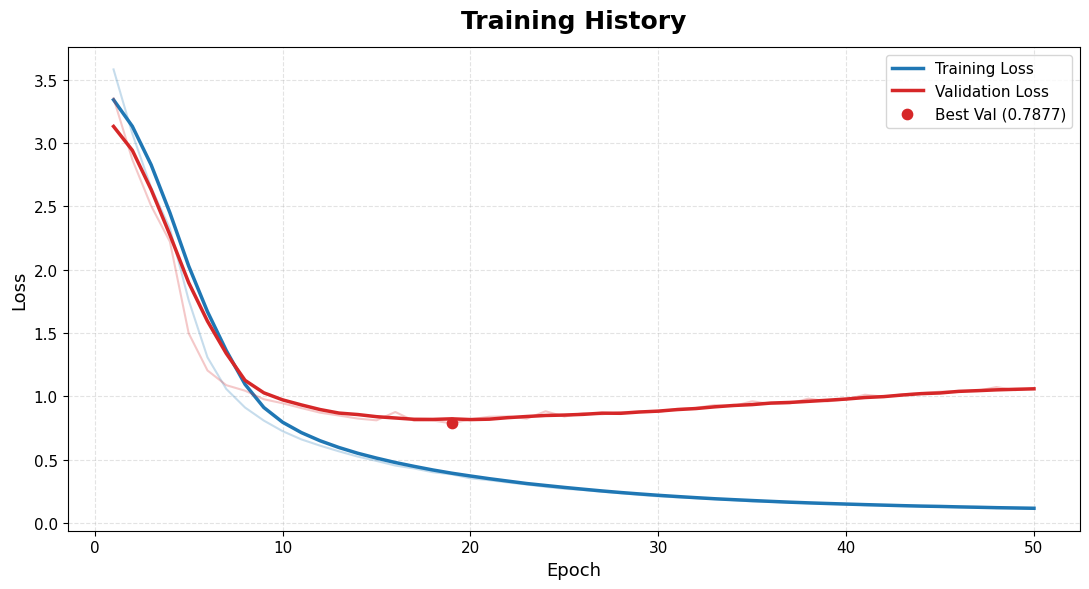

In [27]:
plot_training_history(m_test.train_loss, m_test.val_loss)

Tras incorporar mini-batches, se observa la primera mejora significativa en el tiempo necesario para alcanzar el mejor valor de validation loss. La loss cae de manera pronunciada hasta aproximadamente la época 10 y, a partir de ese punto, el error de validación tiende a estabilizarse. Esta mejora indica que el uso de mini-batches acelera el entrenamiento respecto del gradiente descendente estándar, manteniendo una evolución estable de la loss de validación luego de las primeras épocas.

- **Optimizador Adam**

In [28]:
layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    ADAM(), 
    CrossEntropy()
)

In [29]:
_ = m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 50/50 [00:01<00:00, 34.60ep/s]


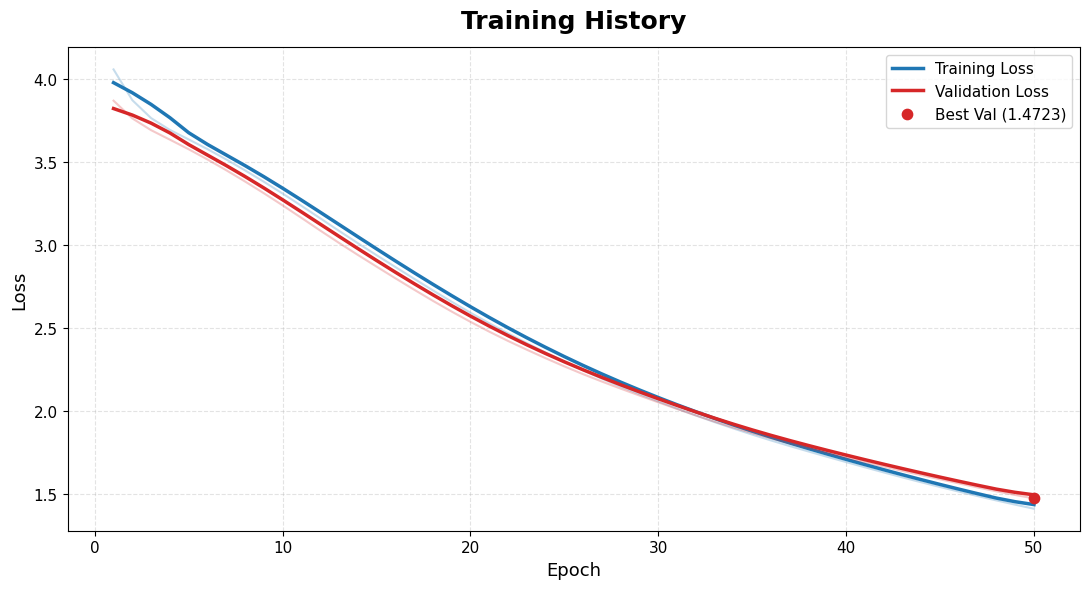

In [30]:
plot_training_history(m_test.train_loss, m_test.val_loss)

Tras la implementación de Adam, se observa una convergencia significativamente más rápida y estable en comparación con Gradient Descent estándar. La función de pérdida presenta una disminución sostenida tanto en training como en validation a lo largo de las épocas, alcanzando valores considerablemente menores que los obtenidos con GD crudo.

- **Regularización (L2, Early Stopping)**

In [31]:
l2_test = 0.01

layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=l2_test),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=l2_test),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=l2_test)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    GradientDescent(learning_rate=0.01), 
    CrossEntropy()
)

In [32]:
_ = m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=10)

Training: 100%|██████████| 50/50 [00:01<00:00, 33.07ep/s]


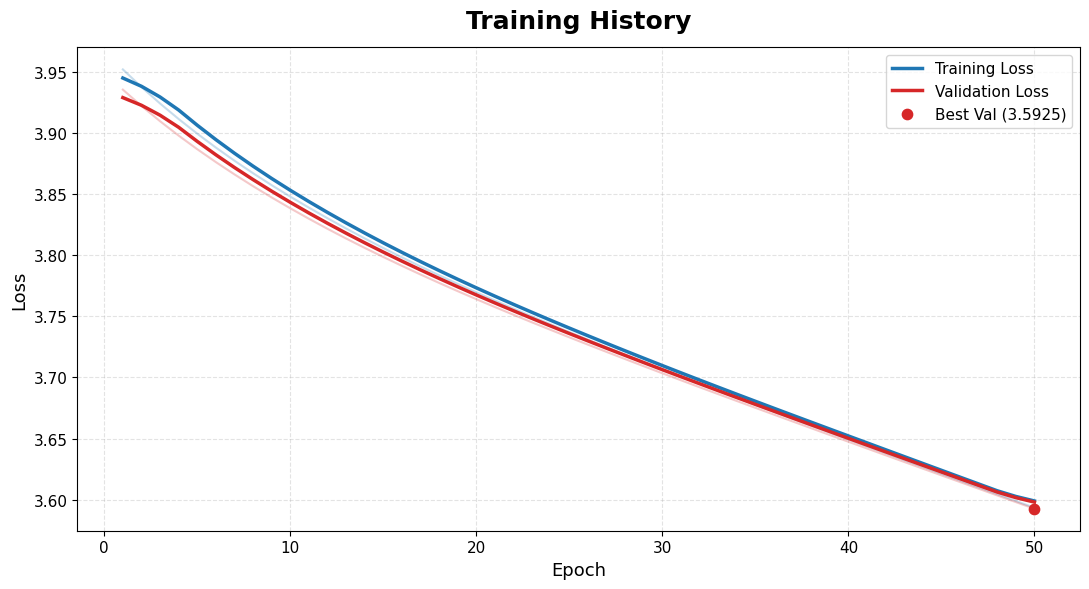

In [33]:
plot_training_history(m_test.train_loss, m_test.val_loss)

Bajo la configuración actual, agregarle una regularización L2 no afecta de manera significativa al modelo, principalmente porque no se llegó a la convergencia en entrenamiento. Se puede ver cómo ambas curvas descienden muy cerca una de la otra, lo que indica que no hay overfitting visible. De manera similar, el mecanismo de early stopping no tuvo efecto, ya que su activación requiere un estancamiento o deterioro en la pérdida de validación, lo cual no ocurrió dado que la validation loss continuó disminuyendo de forma sostenida.

---

**Random Grid Search para M1**

In [34]:
possible_configs = {
    "layers": [
        (128, 64), 
        (256, 128, 64), 
        (256, 128)],
    "l2": [0., 1e-5, 1e-3],
    "batch_size": [128, 256],
    "scheduling": [
        None, 
        {"type": "linear", "lr_min": 1e-5, "k": 1e-5}, 
        {"type": "exponential", "gamma": 0.99}]
}

epochs_search = 50
early_stopping = 5
K_models = 5

models, model_configs = random_grid_search_custom(input_dim, output_dim, X_train_search, 
    y_train_search, X_val_search, y_val_search, epochs_search, K_models, 
    possible_configs, early_stopping=early_stopping)

  0%|          | 0/5 [00:00<?, ?it/s]


Model: 0
Config: {'layers': (256, 128), 'l2': 0.0, 'batch_size': 128, 'scheduling': {'type': 'exponential', 'gamma': 0.99}}



 20%|██        | 1/5 [00:10<00:43, 10.89s/it]

Early stopping after epoch: 12


Model: 1
Config: {'layers': (256, 128, 64), 'l2': 0.0, 'batch_size': 128, 'scheduling': None}



 40%|████      | 2/5 [00:21<00:32, 10.69s/it]

...

Early stopping after epoch: 11


Model: 3
Config: {'layers': (256, 128, 64), 'l2': 0.0, 'batch_size': 128, 'scheduling': None}



 80%|████████  | 4/5 [00:37<00:08,  8.72s/it]

Early stopping after epoch: 9


Model: 4
Config: {'layers': (128, 64), 'l2': 0.0, 'batch_size': 128, 'scheduling': {'type': 'exponential', 'gamma': 0.99}}



100%|██████████| 5/5 [00:42<00:00,  8.52s/it]

Early stopping after epoch: 12



In [ ]:
display(compare_models(models, list(model_configs.keys())).style.hide(axis="index"))

 Model  Best Val Loss  Best Train Loss  Best Epoch  Final Train Loss  Final Val Loss  Epochs Trained
     2       0.802473         0.516097           7          0.264490        0.990981              12
     0       0.828271         0.424184           8          0.238147        0.980854              13
     4       0.842059         0.510653           8          0.291160        0.962964              13
     3       0.853774         0.877017           5          0.392457        0.910373              10
     1       0.867768         0.499110           8          0.326518        1.032342              13


,Model,Best Val Loss,Best Train Loss,Best Epoch,Final Train Loss,Final Val Loss,Epochs Trained
0,2,0.802473,0.516097,7,0.264490,0.990981,12
1,0,0.828271,0.424184,8,0.238147,0.980854,13
2,4,0.842059,0.510653,8,0.291160,0.962964,13
3,3,0.853774,0.877017,5,0.392457,0.910373,10
4,1,0.867768,0.499110,8,0.326518,1.032342,13


<h3 style="color: #00B0FF; font-weight: 400">
    Modelo M1
</h3>

In [36]:
config_m1 = get_best_config(models, model_configs)

m1 = SecuentialNeuralNetwork.build_from_config(input_dim, output_dim, ReLU, 
    SoftMax, config_m1, ADAM, CrossEntropy)

m1_test = deepcopy(m1)

In [37]:
last_epoch_m1 = m1.fit(X_train, y_train, epochs=total_epochs, batch_size=config_m1["batch_size"], 
    X_val=X_val, y_val=y_val, early_stopping=early_stopping)

Training:   5%|▌         | 8/150 [00:40<11:53,  5.03s/ep]

Early stopping after epoch: 8


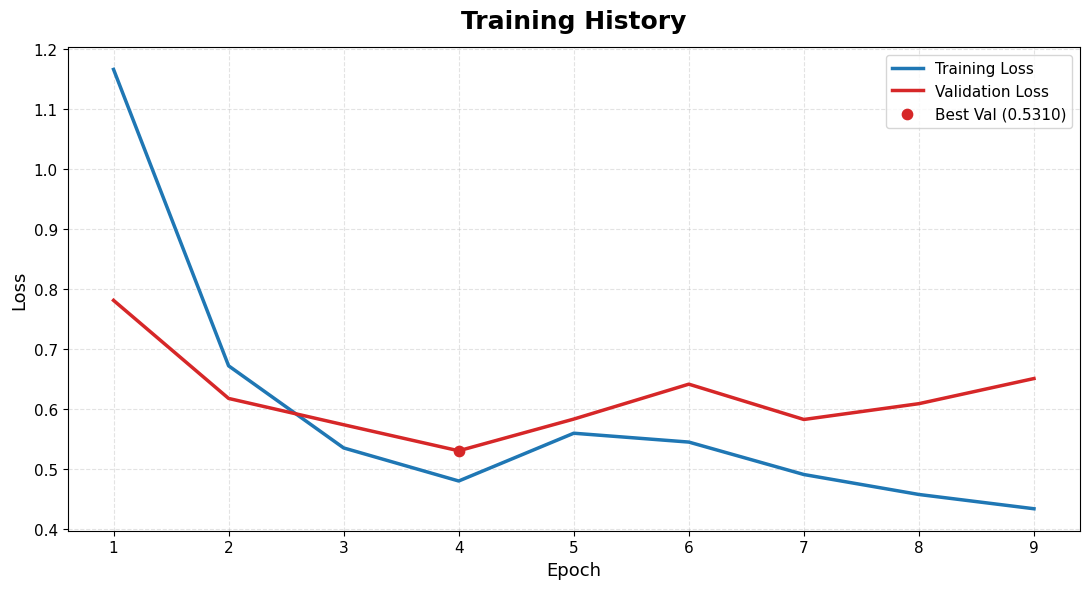

In [38]:
plot_training_history(m1.train_loss, m1.val_loss)

Métricas

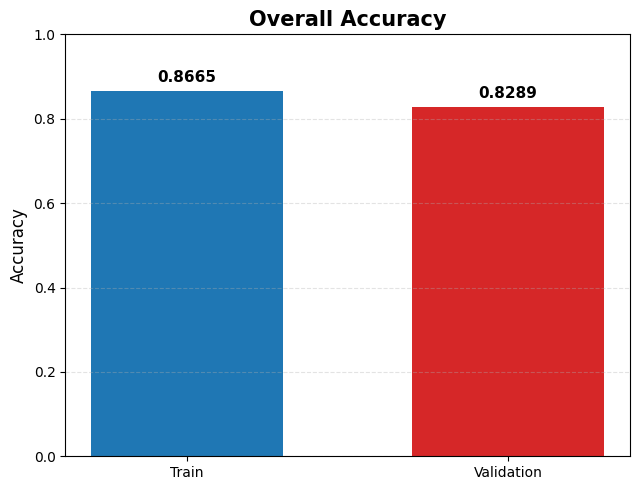

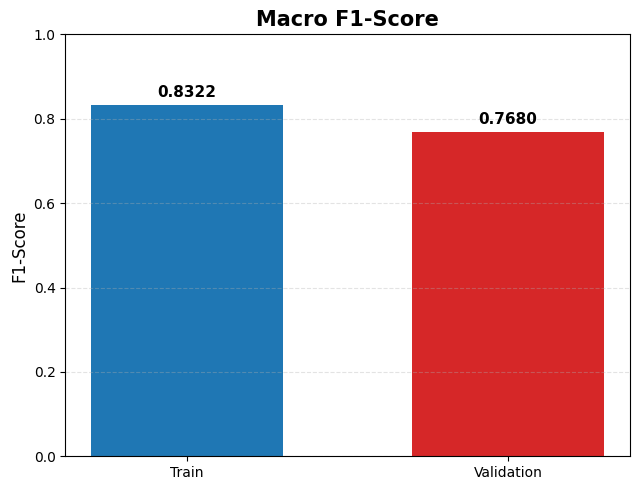

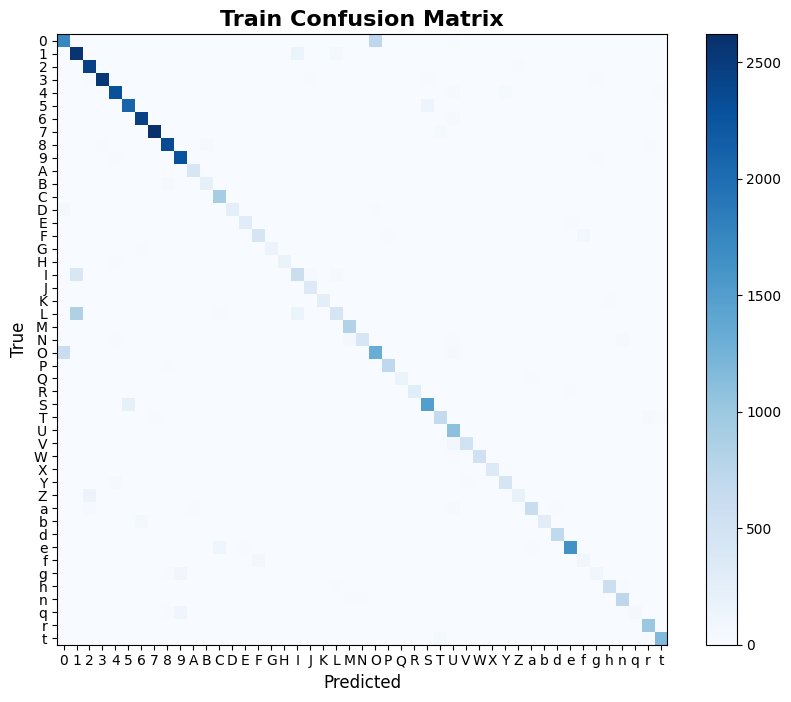

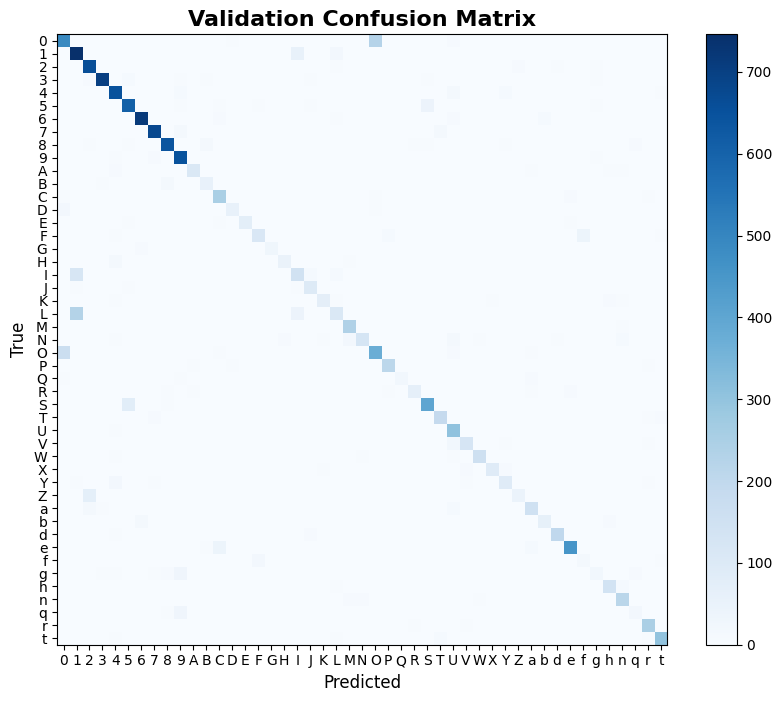

In [39]:
evaluate_model(m1, X_train, y_train, X_val, y_val)

<h2 style="color: #1976D2; font-weight: 500">
    4. Desarrollo de una Red Neuronal con PyTorch
</h2>

Device y Dataset

In [40]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).long()

X_val_tensor = torch.from_numpy(X_val).float()
y_val_tensor = torch.from_numpy(y_val).long()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

del X_train
del y_train
del X_val
del y_val

Using mps device


<h3 style="color: #00B0FF; font-weight: 400">
    Modelo M2
</h3>

In [41]:
config_m2 = config_m1
m2 = MLP(input_dim, config_m2["layers"], output_dim, dropout=0., activation=nn.ReLU)
optimizer_m2 = torch.optim.Adam(m2.parameters(), weight_decay=config_m2["l2"])
loss_fn_m2 = torch.nn.CrossEntropyLoss()

train_loader_m2 = DataLoader(
    train_dataset,
    batch_size=config_m2["batch_size"],
    shuffle=True
)

val_loader_m2 = DataLoader(
    val_dataset,
    batch_size=config_m2["batch_size"],
    shuffle=False
)

m2_test = deepcopy(m2)

Training

In [42]:
m2 = m2.to(device)

train_loss, val_loss, last_epoch_m2 = train_and_eval(train_loader_m2, val_loader_m2, m2, loss_fn_m2, 
    optimizer_m2, device, epochs=total_epochs, early_stopping=early_stopping, 
    scheduling=config_m2["scheduling"])

 10%|█         | 15/150 [00:22<03:20,  1.48s/it]

Early stopping after epoch: 15


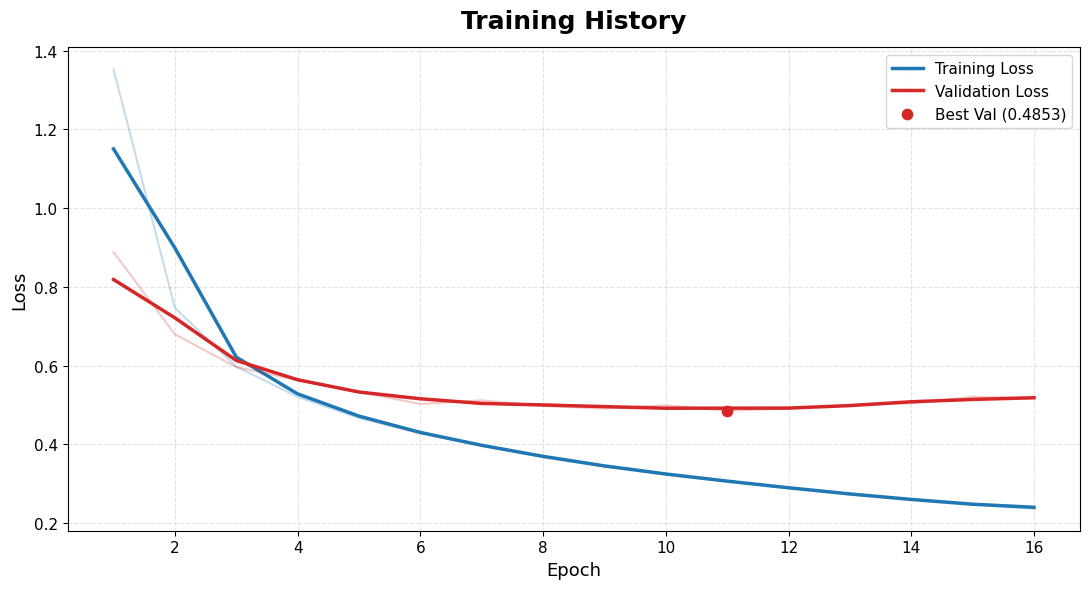

In [43]:
plot_training_history(train_loss, val_loss)

Métricas

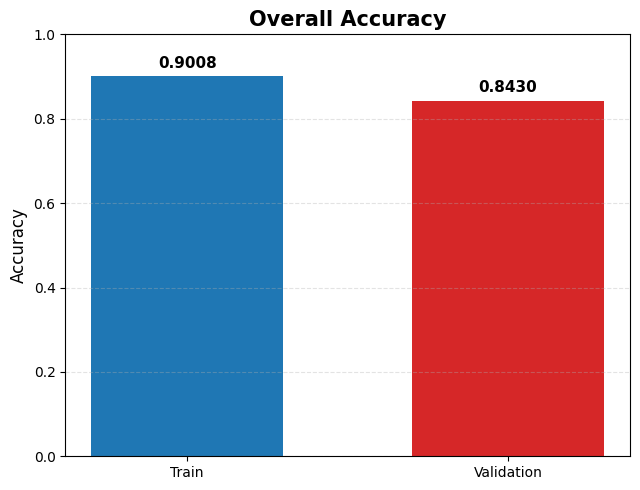

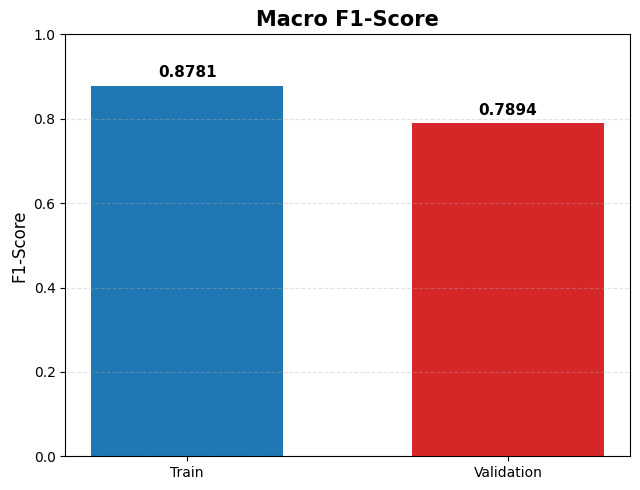

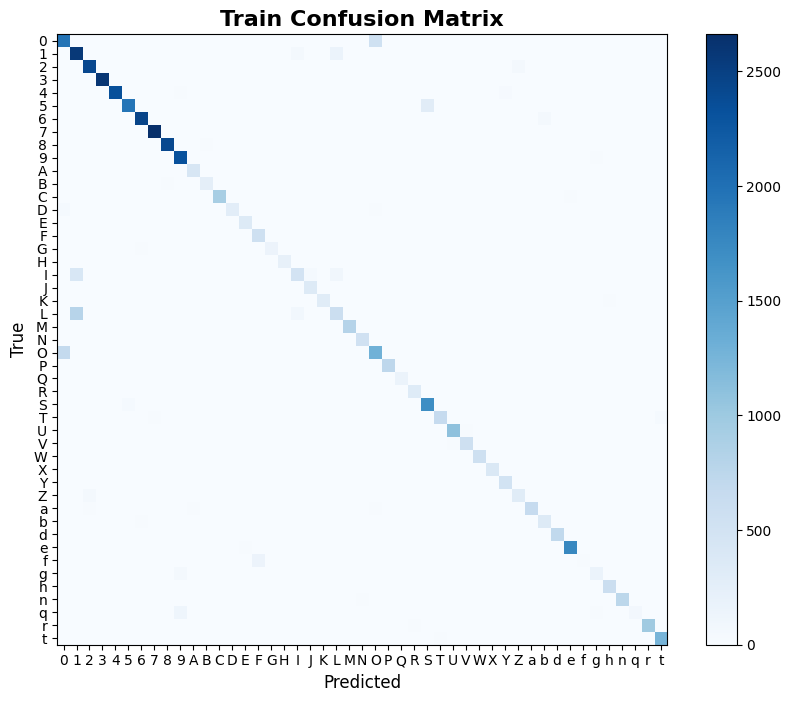

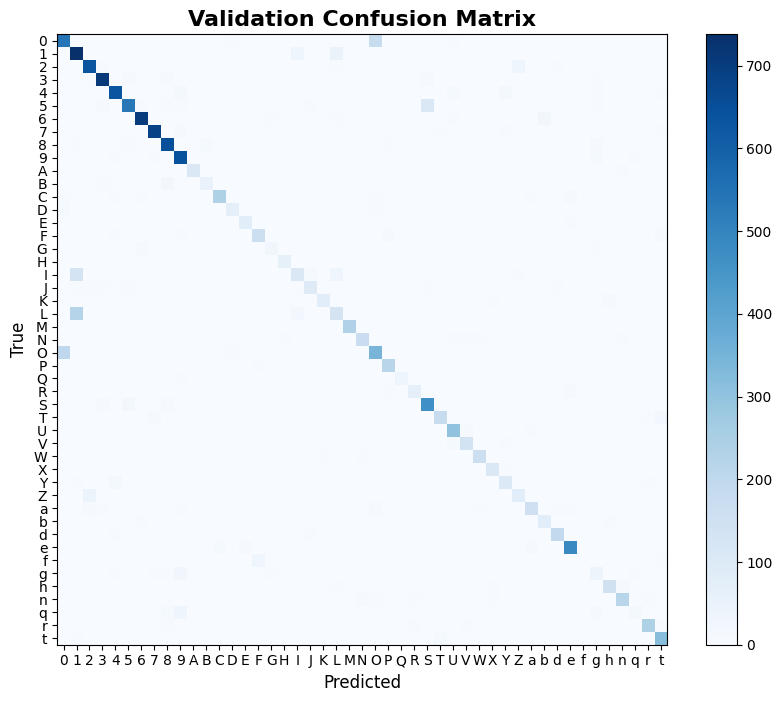

In [44]:
evaluate_model(
    m2, 
    X_train_tensor.detach().cpu().numpy(), 
    y_train_tensor.detach().cpu().numpy(), 
    X_val_tensor.detach().cpu().numpy(), 
    y_val_tensor.detach().cpu().numpy(),
    device=device
)

**Random Grid Search para M3**

In [45]:
X_train_search_tensor = torch.from_numpy(X_train_search).float()
y_train_search_tensor = torch.from_numpy(y_train_search).long()

X_val_search_tensor = torch.from_numpy(X_val_search).float()
y_val_search_tensor = torch.from_numpy(y_val_search).long()

del X_train_search
del y_train_search
del X_val_search
del y_val_search

train_search_dataset = TensorDataset(X_train_search_tensor, y_train_search_tensor)
val_search_dataset = TensorDataset(X_val_search_tensor, y_val_search_tensor)

possible_configs = {
    "layers": [
        [256],
        [512],
        [768],
        [128, 64],
        [256, 128],
        [512, 256],
        [512, 256, 128],
    ],
    "dropout": [0.0, 0.1, 0.2],
    "l2": [0.0, 1e-5],
    "batch_size": [64, 128, 256],
    "lr": [1e-3, 5e-4, 1e-4],
    "optimizer": [torch.optim.AdamW],
    "activation": [nn.ReLU, nn.LeakyReLU, nn.SiLU],
    "batch_norm": [True, False],
    "scheduling": [
        None, 
        {"type": "exponential", "gamma": 0.99}],
    "label_smoothing": [0., 0.05, 0.1]
}

epochs_search = 100
K_models = 15

In [46]:
models, model_configs = random_grid_search_torch(input_dim, output_dim, train_search_dataset, val_search_dataset, 
    epochs_search, K_models, possible_configs, early_stopping, device)

  0%|          | 0/15 [00:00<?, ?it/s]


Model: 0
Config: defaultdict(None, {'layers': [512, 256], 'dropout': 0.0, 'l2': 0.0, 'batch_size': 256, 'lr': 0.0005, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'activation': <class 'torch.nn.modules.activation.ReLU'>, 'batch_norm': True, 'scheduling': None, 'label_smoothing': 0.1})



  7%|▋         | 1/15 [00:10<02:24, 10.32s/it]

Early stopping after epoch: 47

Model: 1
Config: defaultdict(None, {'layers': [512, 256], 'dropout': 0.2, 'l2': 0.0, 'batch_size': 256, 'lr': 0.0005, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'activation': <class 'torch.nn.modules.activation.ReLU'>, 'batch_norm': True, 'scheduling': None, 'label_smoothing': 0.0})



 13%|█▎        | 2/15 [00:17<01:49,  8.39s/it]

...

 87%|████████▋ | 13/15 [04:40<01:01, 30.74s/it]

Early stopping after epoch: 30

Model: 13
Config: defaultdict(None, {'layers': [512, 256, 128], 'dropout': 0.0, 'l2': 0.0, 'batch_size': 256, 'lr': 0.0001, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'activation': <class 'torch.nn.modules.activation.SiLU'>, 'batch_norm': False, 'scheduling': None, 'label_smoothing': 0.05})



 93%|█████████▎| 14/15 [05:04<00:28, 28.57s/it]


Model: 14
Config: defaultdict(None, {'layers': [128, 64], 'dropout': 0.0, 'l2': 1e-05, 'batch_size': 64, 'lr': 0.0001, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'activation': <class 'torch.nn.modules.activation.SiLU'>, 'batch_norm': True, 'scheduling': None, 'label_smoothing': 0.1})



100%|██████████| 15/15 [06:18<00:00, 25.21s/it]


In [ ]:
display(compare_models(models, list(model_configs.keys())).style.hide(axis="index"))

 Model  Best Val Loss  Best Train Loss  Best Epoch  Final Train Loss  Final Val Loss  Epochs Trained
     1       0.669717         0.401028          27          0.358137        0.678638              32
     2       0.677694         0.428541          30          0.379186        0.687909              35
     8       0.703626         0.296217          14          0.207203        0.760533              19
    11       0.750903         0.597586         100          0.597586        0.750903             100
     3       0.755734         0.382254          17          0.286044        0.827532              22
     5       0.917967         0.739283         100          0.739283        0.917967             100
    13       1.082908         0.853722          97          0.843431        1.086429             100
     7       1.204655         0.921825          44          0.900707        1.208888              49
     4       1.235812         1.054766         100          1.054766        1.235812       

,Model,Best Val Loss,Best Train Loss,Best Epoch,Final Train Loss,Final Val Loss,Epochs Trained
0,1,0.669717,0.401028,27,0.358137,0.678638,32
1,2,0.677694,0.428541,30,0.379186,0.687909,35
2,8,0.703626,0.296217,14,0.207203,0.760533,19
3,11,0.750903,0.597586,100,0.597586,0.750903,100
4,3,0.755734,0.382254,17,0.286044,0.827532,22
5,5,0.917967,0.739283,100,0.739283,0.917967,100
6,13,1.082908,0.853722,97,0.843431,1.086429,100
7,7,1.204655,0.921825,44,0.900707,1.208888,49
8,4,1.235812,1.054766,100,1.054766,1.235812,100
9,6,1.245150,0.895946,14,0.844100,1.258955,19


<h3 style="color: #00B0FF; font-weight: 400">
    Modelo M3
</h3>

In [48]:
config_m3 = get_best_config(models, model_configs)

m3 = MLP(input_dim, config_m3["layers"], output_dim, config_m3["dropout"], 
    config_m3["activation"], config_m3["batch_norm"])

train_loader_m3 = DataLoader(
    train_dataset,
    batch_size=config_m3["batch_size"],
    shuffle=True
)

val_loader_m3 = DataLoader(
    val_dataset,
    batch_size=config_m3["batch_size"],
    shuffle=False
)

loss_fn_m3 = nn.CrossEntropyLoss(label_smoothing=config_m3["label_smoothing"])
optimizer_m3 = config_m3["optimizer"](m3.parameters(), weight_decay=config_m3["l2"])

m3_test = deepcopy(m3)

In [49]:
m3 = m3.to(device)

train_loss, val_loss, last_epoch_m3 = train_and_eval(train_loader_m3, val_loader_m3, m3, loss_fn_m3, 
    optimizer_m3, device, epochs=total_epochs, early_stopping=early_stopping, 
    scheduling=config_m3["scheduling"])

 11%|█▏        | 17/150 [00:18<02:25,  1.09s/it]

Early stopping after epoch: 17


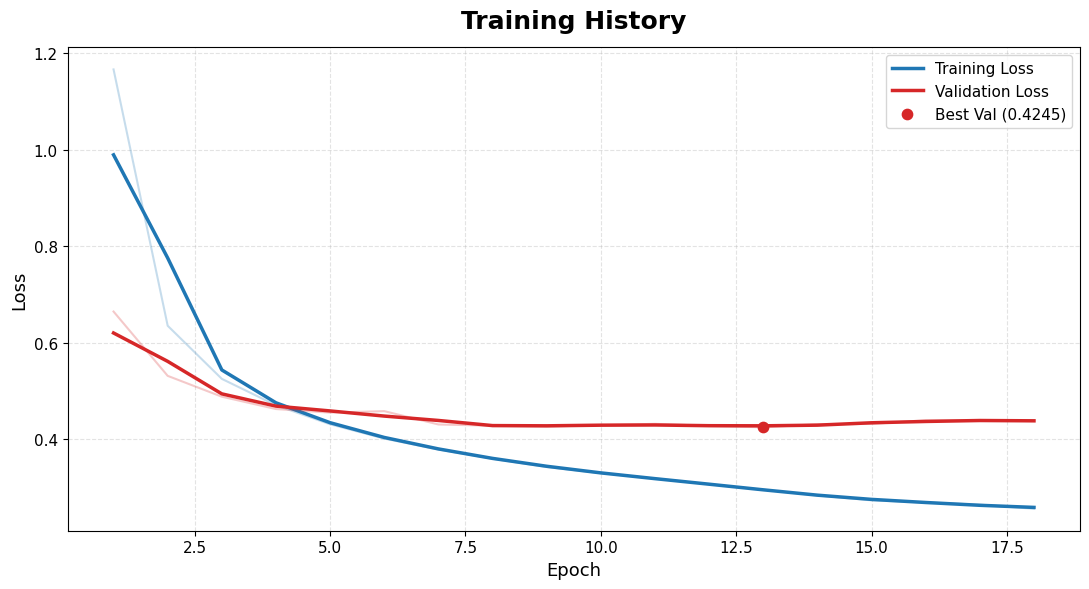

In [50]:
plot_training_history(train_loss, val_loss)

Métricas

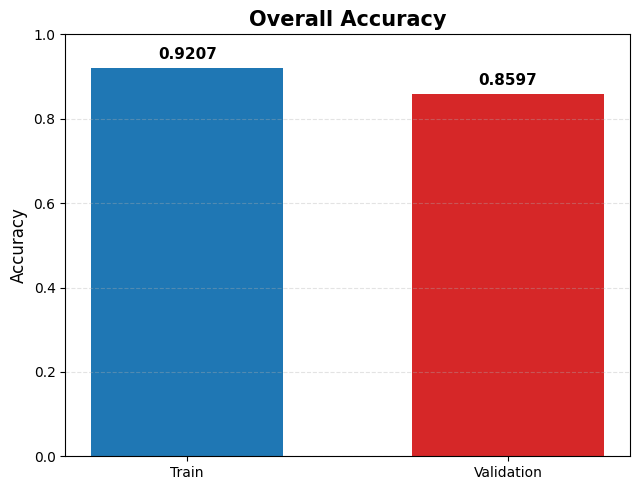

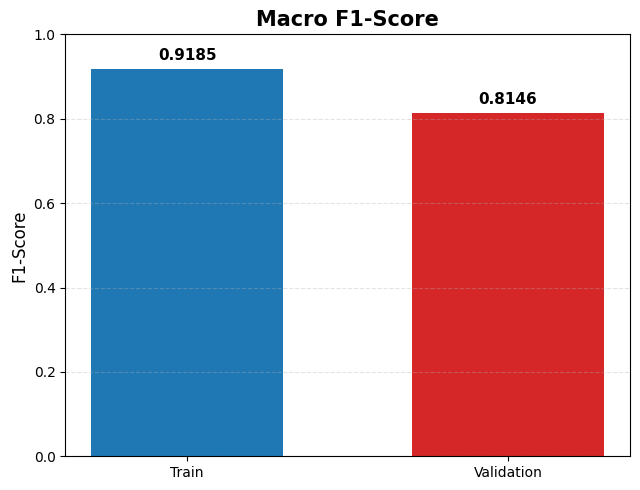

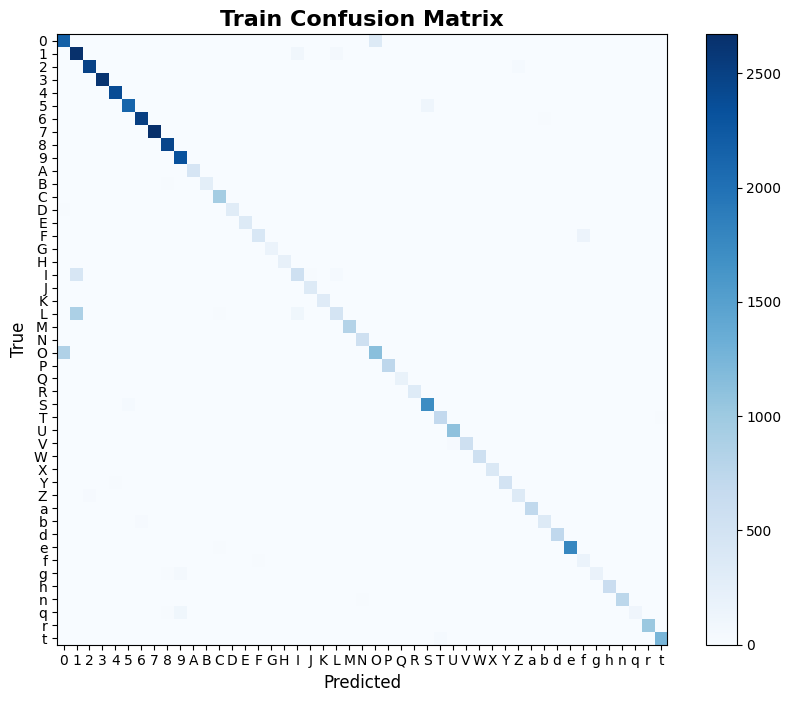

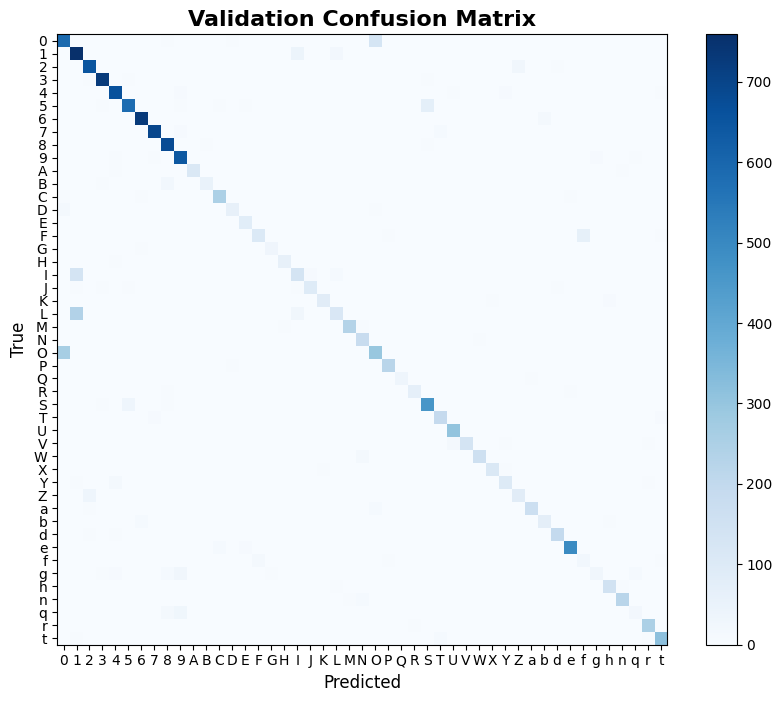

In [51]:
evaluate_model(
    m3, 
    X_train_tensor.detach().cpu().numpy(), 
    y_train_tensor.detach().cpu().numpy(), 
    X_val_tensor.detach().cpu().numpy(), 
    y_val_tensor.detach().cpu().numpy(),
    device=device
)

<h3 style="color: #00B0FF; font-weight: 400">
    Performance de los modelos con respecto a test
</h3>

Primero entreno todos los modelos usando **DEV** con la cantidad de epochs que entrenó para la partición train / val y luego evalúo en todo **TEST**



In [52]:
X_dev_tensor = torch.from_numpy(X_dev).float().to(device)
y_dev_tensor = torch.from_numpy(y_dev).long().to(device)

dev_dataset = TensorDataset(X_dev_tensor, y_dev_tensor)

**M0**

In [53]:
m0_test.fit(X_dev, y_dev, last_epoch_m0, batch_size=None)

y_pred_m0 = m0_test.predict(X_test)

Training: 100%|██████████| 150/150 [00:25<00:00,  5.96ep/s]


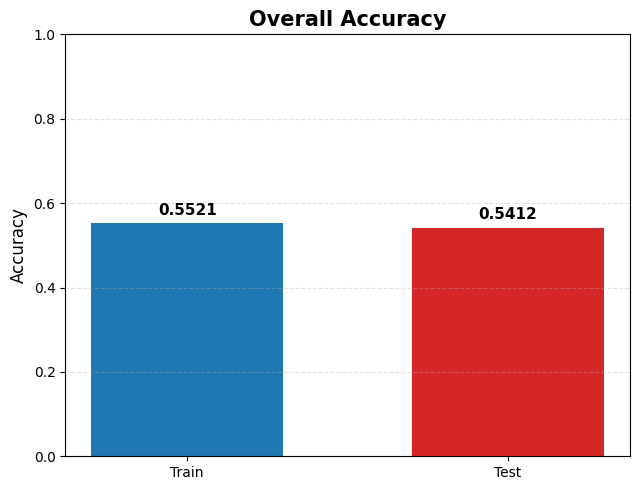

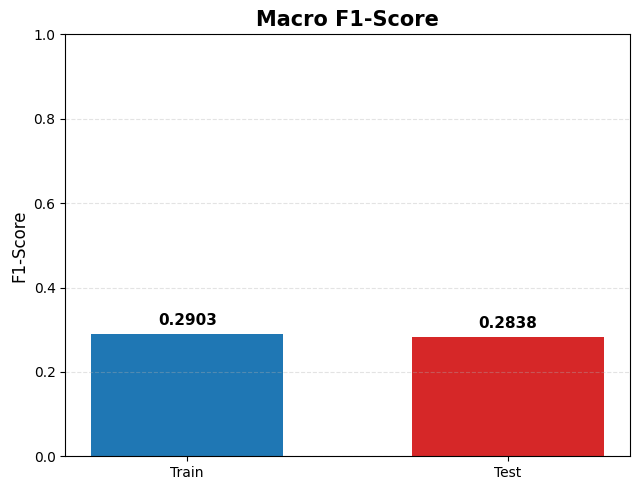

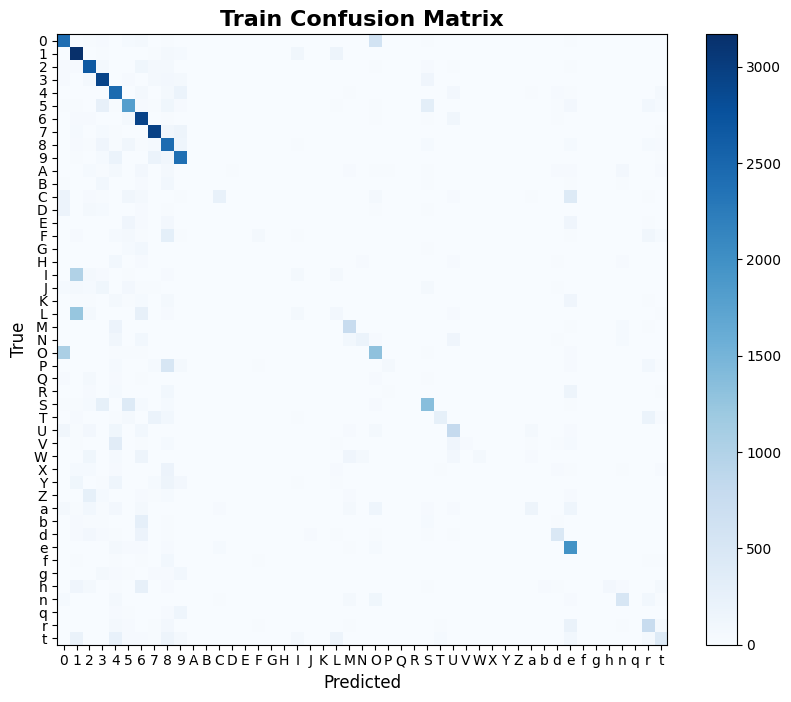

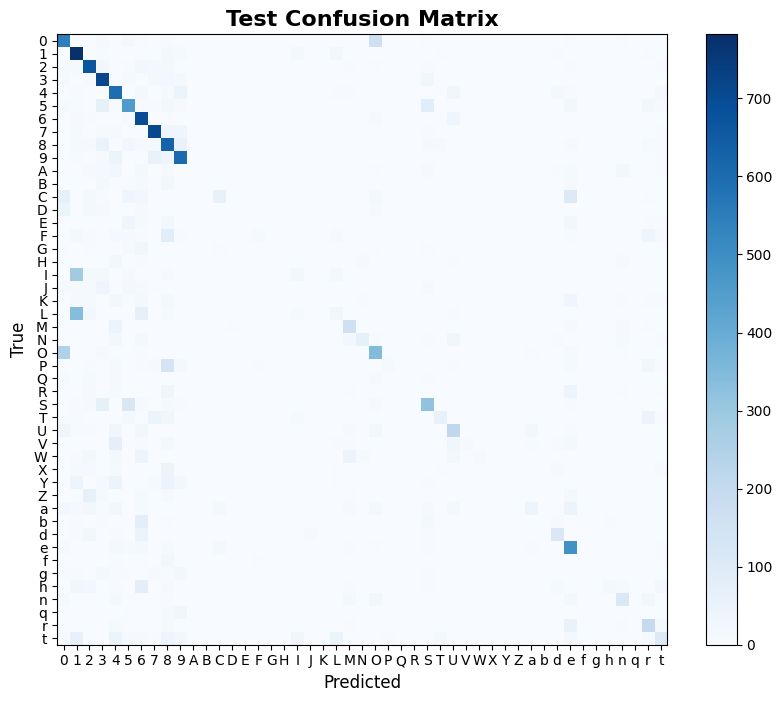

In [54]:
evaluate_model(m0_test, X_dev, y_dev, X_test, y_test, val_name="Test")

**M1**

In [55]:
m1_test.fit(X_dev, y_dev, last_epoch_m1, config_m1["batch_size"])

y_pred_m1 = m1_test.predict(X_test)

Training: 100%|██████████| 4/4 [00:04<00:00,  1.07s/ep]


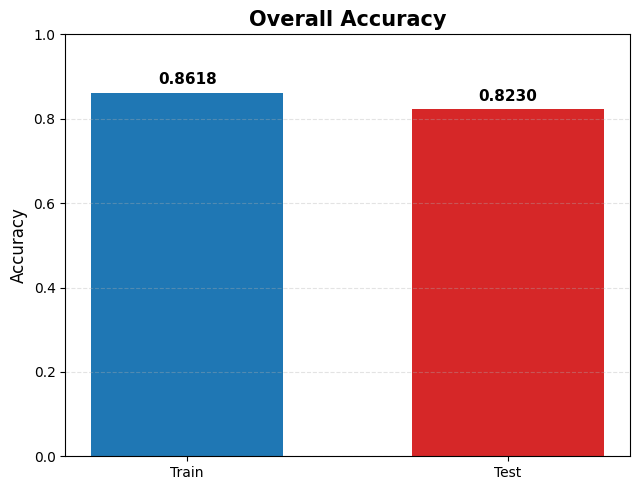

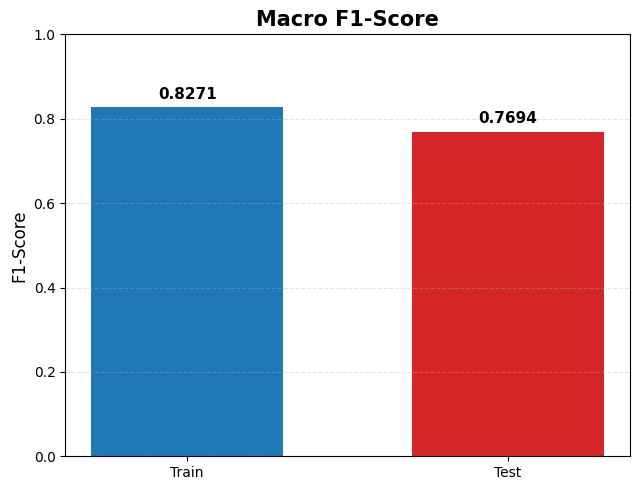

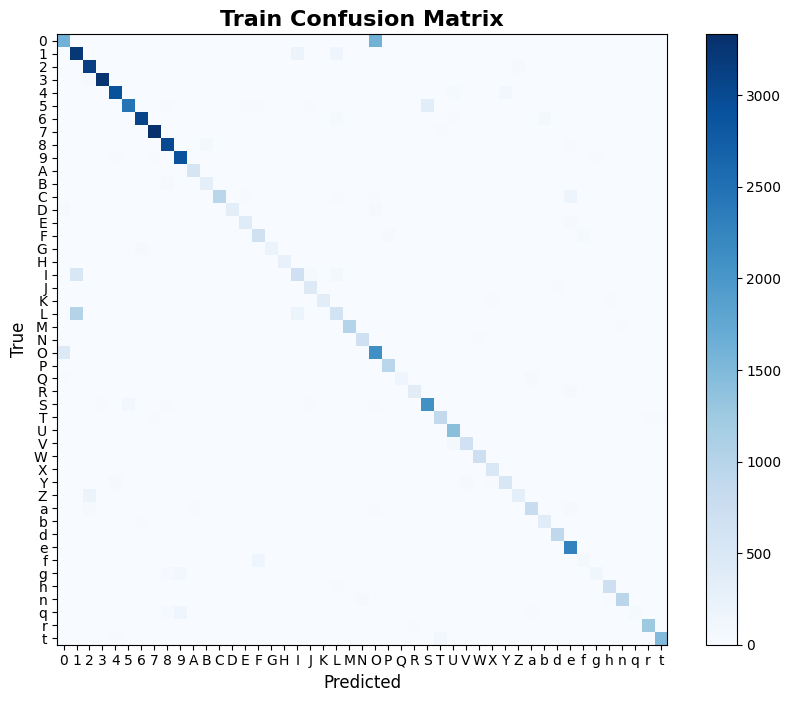

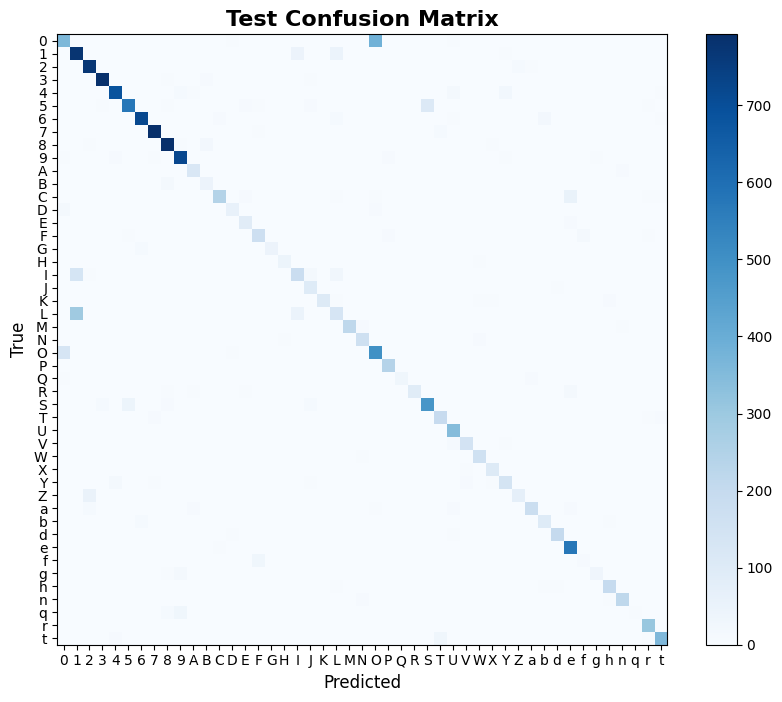

In [56]:
evaluate_model(m1_test, X_dev, y_dev, X_test, y_test, val_name="Test")

**M2**

In [58]:
X_test_tensor = torch.from_numpy(X_test).float().to(device)

dev_loader_m2 = DataLoader(
    dev_dataset,
    batch_size=config_m2["batch_size"],
    shuffle=True
)

m2_test.to(device)

optimizer_m2_test = torch.optim.Adam(m2_test.parameters(), weight_decay=config_m2["l2"])

for t in tqdm(range(last_epoch_m2)):
    train_loop(dev_loader_m2, m2_test, nn.CrossEntropyLoss(), optimizer_m2_test, device)
    
y_pred_m2 = get_predictions(m2_test, X_test, device)

100%|██████████| 11/11 [00:10<00:00,  1.06it/s]


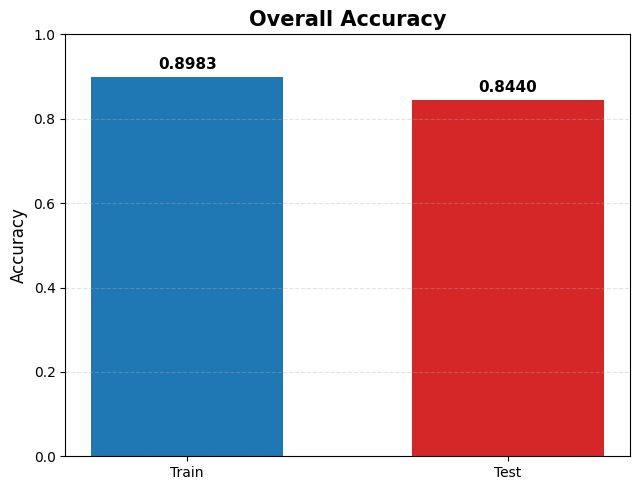

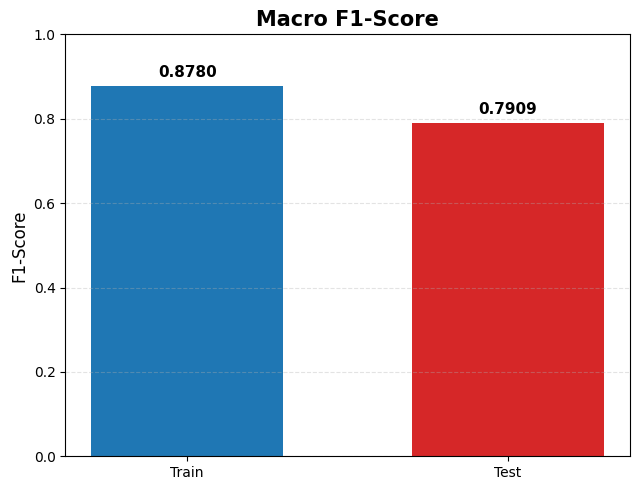

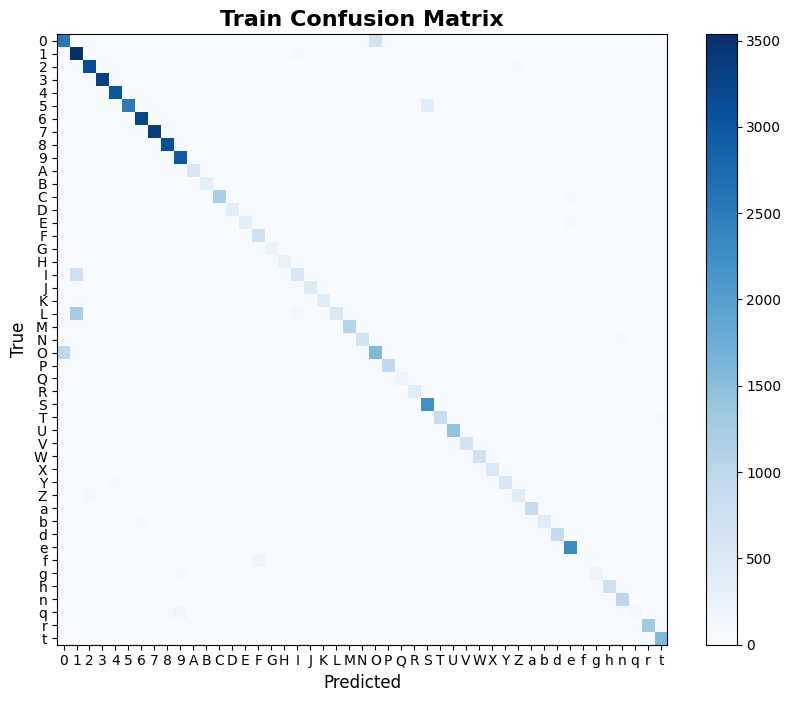

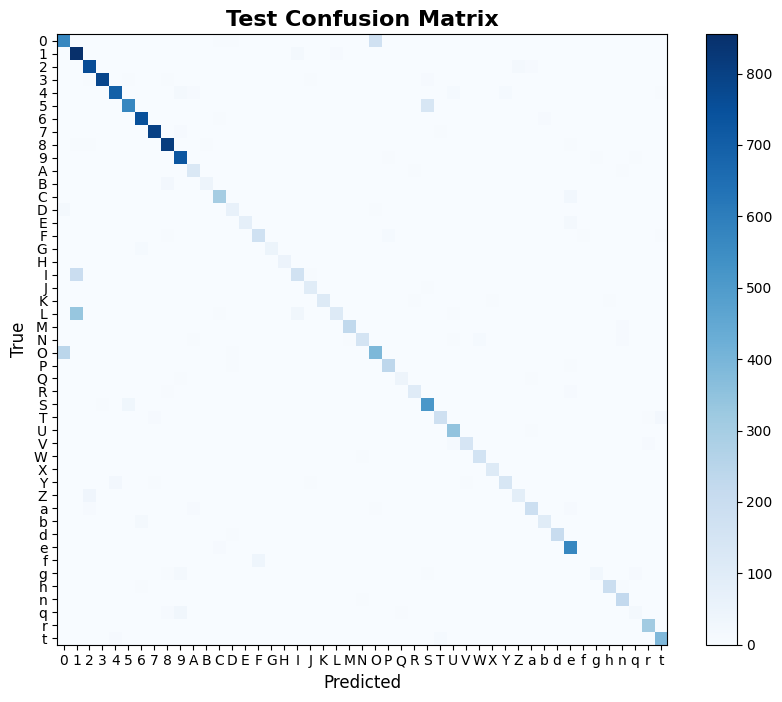

In [59]:
evaluate_model(m2_test, X_dev, y_dev, X_test, y_test, val_name="Test", device=device)

**M3**

In [60]:
dev_loader_m3 = DataLoader(
    dev_dataset,
    batch_size=config_m3["batch_size"],
    shuffle=True
)

m3_test.to(device)

optimizer_m3_test = config_m3["optimizer"](m3_test.parameters(), weight_decay=config_m3["l2"])

for t in tqdm(range(last_epoch_m3)):
    train_loop(dev_loader_m3, m3_test, nn.CrossEntropyLoss(label_smoothing=config_m3["label_smoothing"]), optimizer_m3_test, device)
    
    
y_pred_m3 = get_predictions(m3_test, X_test, device)

100%|██████████| 13/13 [00:12<00:00,  1.08it/s]


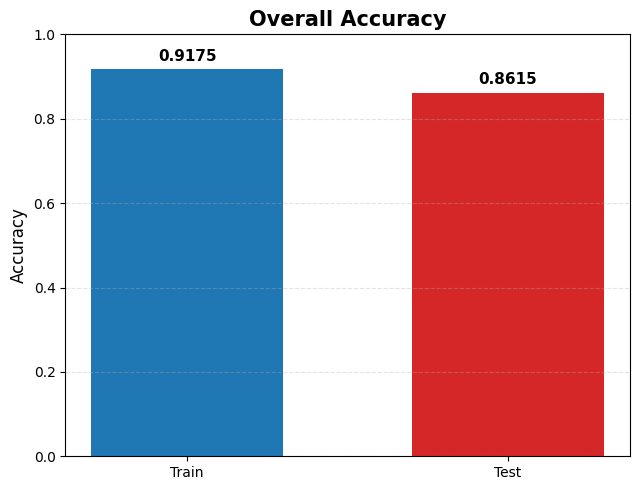

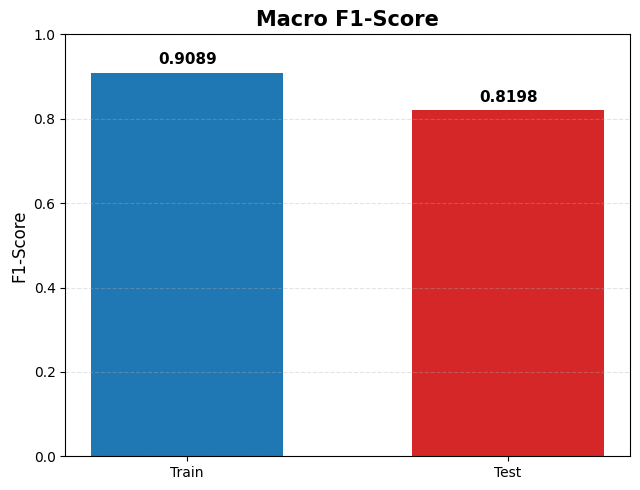

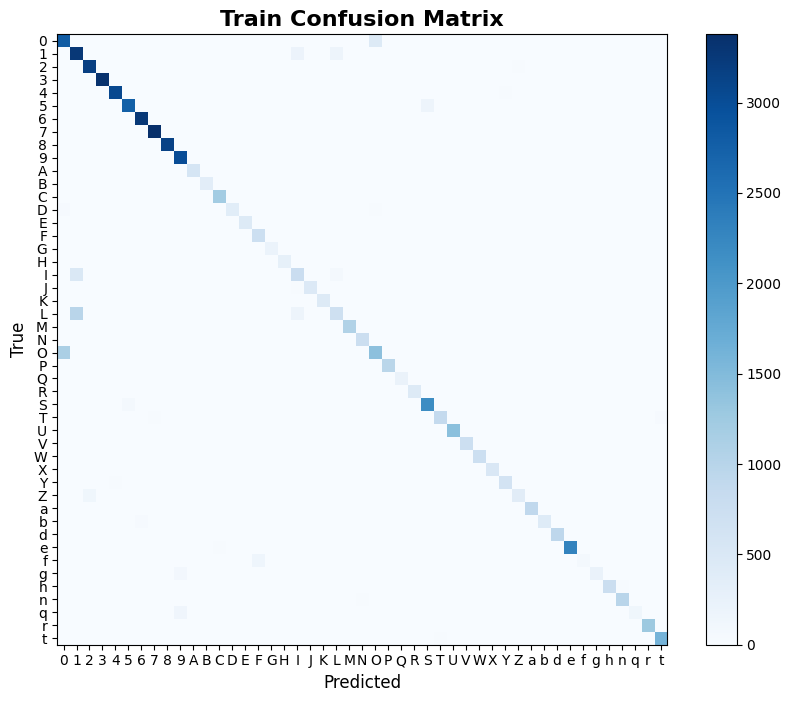

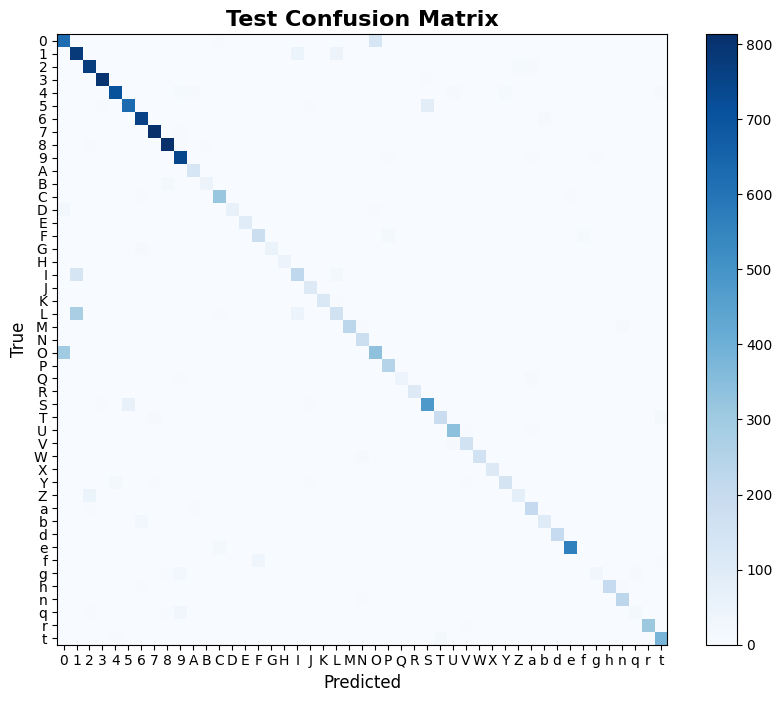

In [61]:
evaluate_model(m3_test, X_dev, y_dev, X_test, y_test, val_name="Test", device=device)

**Gráfico comparativo**

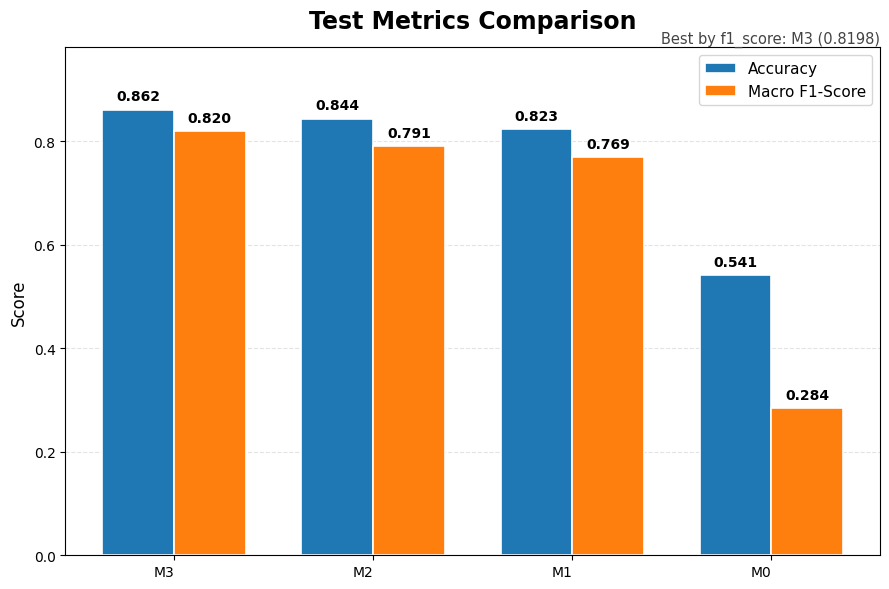

In [65]:
models = {"M0": m0_test, "M1": m1_test, "M2": m2_test, "M3": m3_test}

plot_model_metric_comparison(models, X_test, y_test, device=device)

En términos de desempeño sobre el conjunto de test, los modelos implementados con PyTorch superaron claramente a las versiones custom. En particular, M3 fue el mejor modelo, con accuracy y macro-F1 más altos, seguido por M2 y M1 . En cambio, M0 quedó bastante por debajo, lo que se debe al entrenamiento de este modelo, que fue limitado por el costo computacional. Que el F1 haya sido menor que el accuracy para todos los modelos indica que hay clases más difíciles de predecir que otras. Esto se puede observar en las matrices de confusión de los modelos, ya que por ejemplo, todos los modelos confunden 'O' con '0', 'L' con '1', 'I' con '1' y 'S' con '5', entre otras. Esto era algo esperable por la similaridad de los caracteres.

**Robustez de los modelos**

In [63]:
noise_levels = [0.1, 0.2, 0.3]

df = evaluate_noise_robustness(models, X_test, y_test, noise_levels, device)

display(df.style.hide(axis="index").format({"noise_level": "{:.1f}"}))

model,noise_level,accuracy,f1_score
M0,0.0,0.541165,0.283836
M0,0.1,0.534803,0.277296
M0,0.2,0.518498,0.265714
M0,0.3,0.473658,0.241355
M1,0.0,0.823050,0.769404
M1,0.1,0.747946,0.674590
M1,0.2,0.482305,0.415696
M1,0.3,0.230004,0.192887
M2,0.0,0.843987,0.790871
M2,0.1,0.740350,0.659519


# COMPLETAR CON DATOS

El análisis de robustez muestra que el modelo con mejor desempeño en Test también fue el más robusto ante ruido moderado. Por ejemplo, con noise = 0.1, M3 mantiene accuracy $\approx$ 0.77 y macro-F1 $\approx$ 0.7, por encima de M2 y M1. Sin embargo, cuando el ruido crece (0.2 y 0.3), todos los modelos colapsan.

---

**Modelo elegido para producción**

El modelo elegido para llevar a producción es el **M3**. En primer lugar, es el modelo que alcanzó las mejores métricas y los mejores resultados en la prueba de robustez. 

Además, es el modelo que más cantidad de optimizaciones tiene y además, está implementado en Pytorch, algo que lo hace más eficiente que las implementaciones custom, aprovechando la aceleración por GPU y un entrenamiento más estable. 